# 06 — Class Distribution & Active Learning Analysis

Analyse:
1. Class distribution across train/val/test splits
2. How filtering to ≥10 samples changed the distribution
3. Active learning results — which classes are most uncertain
4. Identify priority classes for data collection

In [9]:
import os
import numpy as np
import json
import matplotlib.pyplot as plt
from collections import Counter

DATA_DIR = os.path.join('..', 'data')
SAVED_MODEL_DIR = os.path.join('..', 'saved_models')

## 1. Load Data & Label Map

In [10]:
X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
X_val = np.load(os.path.join(DATA_DIR, 'X_val.npy'))
X_test = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
y_val = np.load(os.path.join(DATA_DIR, 'y_val.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Total samples: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")

Train: (2965, 30, 132)  Val: (635, 30, 132)  Test: (636, 30, 132)
Total samples: 4236


In [11]:
with open(os.path.join(SAVED_MODEL_DIR, 'label_map.json')) as f:
    label_map = json.load(f)
label_map = {int(k): v for k, v in label_map.items()}

with open(os.path.join(SAVED_MODEL_DIR, 'class_mapping.json')) as f:
    class_map = json.load(f)
class_map = {int(k): int(v) for k, v in class_map.items()}

print(f"Total classes: {len(label_map)}")
print(f"Filtered classes (≥10 samples): {len(class_map)}")

Total classes: 383
Filtered classes (≥10 samples): 98


## 2. Distribution Across All Classes (Train Set)

In [12]:
y_train_idx = np.argmax(y_train, axis=1)
y_val_idx = np.argmax(y_val, axis=1)
y_test_idx = np.argmax(y_test, axis=1)

def analyze_distribution(y_idx, name):
    unique, counts = np.unique(y_idx, return_counts=True)
    print(f"\n{'='*40}")
    print(f"{name} SET DISTRIBUTION")
    print(f"{'='*40}")
    print(f"  Classes present: {len(unique)}")
    print(f"  Min samples/class: {counts.min()}")
    print(f"  Max samples/class: {counts.max()}")
    print(f"  Mean samples/class: {counts.mean():.2f}")
    print(f"  Median samples/class: {np.median(counts):.2f}")
    for thresh in [1, 2, 5, 10, 20]:
        rare = np.sum(counts < thresh)
        print(f"  Classes with <{thresh:2d} samples: {rare:3d} ({rare/len(unique)*100:.1f}%)")
    return counts

train_counts = analyze_distribution(y_train_idx, "TRAIN")
val_counts = analyze_distribution(y_val_idx, "VAL")
test_counts = analyze_distribution(y_test_idx, "TEST")


TRAIN SET DISTRIBUTION
  Classes present: 370
  Min samples/class: 1
  Max samples/class: 80
  Mean samples/class: 8.01
  Median samples/class: 5.00
  Classes with < 1 samples:   0 (0.0%)
  Classes with < 2 samples:  49 (13.2%)
  Classes with < 5 samples: 176 (47.6%)
  Classes with <10 samples: 272 (73.5%)
  Classes with <20 samples: 332 (89.7%)

VAL SET DISTRIBUTION
  Classes present: 247
  Min samples/class: 1
  Max samples/class: 20
  Mean samples/class: 2.57
  Median samples/class: 2.00
  Classes with < 1 samples:   0 (0.0%)
  Classes with < 2 samples:  99 (40.1%)
  Classes with < 5 samples: 217 (87.9%)
  Classes with <10 samples: 243 (98.4%)
  Classes with <20 samples: 246 (99.6%)

TEST SET DISTRIBUTION
  Classes present: 245
  Min samples/class: 1
  Max samples/class: 23
  Mean samples/class: 2.60
  Median samples/class: 2.00
  Classes with < 1 samples:   0 (0.0%)
  Classes with < 2 samples: 107 (43.7%)
  Classes with < 5 samples: 216 (88.2%)
  Classes with <10 samples: 238 (97.

## 3. Distribution After Filtering (≥10 samples in Train)

In [13]:
filtered_class_ids = sorted(class_map.keys())

# Train counts for filtered classes
train_counts_filtered = np.zeros(len(filtered_class_ids))
for i, orig_id in enumerate(filtered_class_ids):
    train_counts_filtered[i] = (y_train_idx == orig_id).sum()

print(f"\n{'='*40}")
print("FILTERED CLASSES (≥10 samples in train)")
print(f"{'='*40}")
print(f"  Number of classes: {len(filtered_class_ids)}")
print(f"  Min samples: {train_counts_filtered.min():.0f}")
print(f"  Max samples: {train_counts_filtered.max():.0f}")
print(f"  Mean samples: {train_counts_filtered.mean():.2f}")
print(f"  Median samples: {np.median(train_counts_filtered):.2f}")
print(f"  Train samples: {train_counts_filtered.sum():.0f}")


FILTERED CLASSES (≥10 samples in train)
  Number of classes: 98
  Min samples: 10
  Max samples: 80
  Mean samples: 20.00
  Median samples: 18.00
  Train samples: 1960


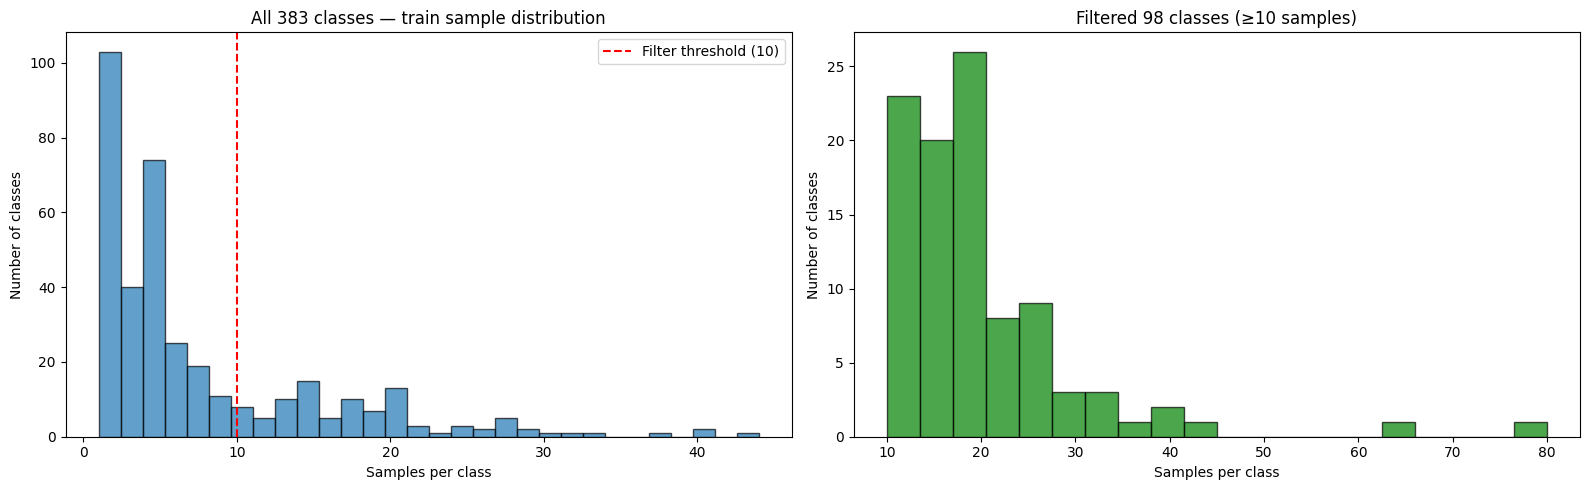

In [14]:
# Distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# All classes
axes[0].hist(train_counts[train_counts < 50], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=10, color='red', linestyle='--', label='Filter threshold (10)')
axes[0].set_title('All 383 classes — train sample distribution')
axes[0].set_xlabel('Samples per class')
axes[0].set_ylabel('Number of classes')
axes[0].legend()

# Filtered only
axes[1].hist(train_counts_filtered, bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title(f'Filtered {len(filtered_class_ids)} classes (≥10 samples)')
axes[1].set_xlabel('Samples per class')
axes[1].set_ylabel('Number of classes')

plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=150)
plt.show()

## 4. Rarest & Most Common Classes

In [15]:
unique_all, counts_all = np.unique(y_train_idx, return_counts=True)
sorted_idx = np.argsort(counts_all)

print("\n--- 20 RAREST CLASSES (train) ---")
for idx in sorted_idx[:20]:
    cid = unique_all[idx]
    name = label_map.get(cid, f"Class_{cid}")
    print(f"  {name:25s} {counts_all[idx]:2d} samples")

print("\n--- 20 MOST COMMON CLASSES (train) ---")
for idx in sorted_idx[-20:][::-1]:
    cid = unique_all[idx]
    name = label_map.get(cid, f"Class_{cid}")
    print(f"  {name:25s} {counts_all[idx]:2d} samples")


--- 20 RAREST CLASSES (train) ---
  Swim                       1 samples
  Train                      1 samples
  Cow                        1 samples
  Relations                  1 samples
  Count                      1 samples
  Tree                       1 samples
  Sit                        1 samples
  Milk                       1 samples
  Tire                       1 samples
  Ugly                       1 samples
  Chain                      1 samples
  Next                       1 samples
  Careful                    1 samples
  No                         1 samples
  Bus station                1 samples
  Brother in law             1 samples
  Bring                      1 samples
  Clearly                    1 samples
  Break                      1 samples
  Sand                       1 samples

--- 20 MOST COMMON CLASSES (train) ---
  Thank you                 80 samples
  Hello                     65 samples
  You                       44 samples
  Good                      

## 5. Active Learning — Most Uncertain Predictions

In [16]:
al_path = os.path.join(SAVED_MODEL_DIR, 'active_learning_samples.json')
if os.path.exists(al_path):
    with open(al_path) as f:
        al_samples = json.load(f)
    
    print(f"Active learning samples loaded: {len(al_samples)}")

    # Determine mode based on available keys
    has_uncertainty = all('uncertainty' in s for s in al_samples if 'confidence' in s)
    
    if has_uncertainty and len(al_samples) > 0:
        al_sorted = sorted(al_samples, key=lambda x: x['uncertainty'], reverse=True)
        correct = sum(1 for s in al_sorted if s['correct'])
        avg_conf = np.mean([s['confidence'] for s in al_sorted])
        print(f"  Correct: {correct}/{len(al_sorted)} ({correct/len(al_sorted)*100:.1f}%)")
        print(f"  Avg confidence: {avg_conf:.3f}")
        print(f"  Avg uncertainty: {1 - avg_conf:.3f}")
        
        print("\n--- TOP 15 MOST UNCERTAIN SAMPLES ---")
        for i, s in enumerate(al_sorted[:15]):
            mark = '✓' if s['correct'] else '✗'
            print(f"  {i+1:2d}. {mark} True: {s['true_class']:20s} | "
                  f"Pred: {s['predicted_class']:20s} | Conf: {s['confidence']:.3f} | "
                  f"Unc: {s['uncertainty']:.3f}")
    else:
        # by_class mode — no uncertainty key; show all sorted by confidence (ascending)
        al_sorted = sorted(al_samples, key=lambda x: x.get('confidence', 1))
        correct = sum(1 for s in al_sorted if 'correct' in s and s['correct'])
        total = len(al_sorted)
        avg_conf = np.mean([s['confidence'] for s in al_sorted if 'confidence' in s])
        print(f"  Correct: {correct}/{total} ({correct/total*100:.1f}%)" if total else "  No samples")
        print(f"  Avg confidence: {avg_conf:.3f}")
        
        print("\n--- MOST UNCERTAIN (by_class mode, lowest confidence first) ---")
        for i, s in enumerate(al_sorted[:15]):
            conf = s.get('confidence', 'N/A')
            if 'correct' in s:
                mark = '✓' if s['correct'] else '✗'
                print(f"  {i+1:2d}. {mark} True: {s.get('true_class','?'):20s} | "
                      f"Pred: {s.get('predicted_class','?'):20s} | Conf: {conf}")
            else:
                print(f"  {i+1:2d}.   Class: {s.get('class_name','?'):20s} | (needs prediction)")
else:
    print(f"Active learning file not found at {al_path}")

Active learning samples loaded: 22
  Correct: 0/22 (0.0%)
  Avg confidence: 0.479

--- MOST UNCERTAIN (by_class mode, lowest confidence first) ---
   1. ✗ True: Cook                 | Pred: Ayubowan             | Conf: 0.15996351838111877
   2. ✗ True: Cough                | Pred: Addition             | Conf: 0.1637565642595291
   3. ✗ True: Cough                | Pred: 6. six               | Conf: 0.19921675324440002
   4. ✗ True: Break                | Pred: Camera               | Conf: 0.26481759548187256
   5. ✗ True: Tell                 | Pred: Bag                  | Conf: 0.271502822637558
   6. ✗ True: Sell                 | Pred: Clearly              | Conf: 0.28179705142974854
   7. ✗ True: Brown                | Pred: Cow                  | Conf: 0.30571162700653076
   8. ✗ True: Multiplication       | Pred: Article              | Conf: 0.3094295263290405
   9. ✗ True: Cook                 | Pred: 5. five              | Conf: 0.34637588262557983
  10. ✗ True: Throw          

## 6. Classes Needing More Data

Classes with <10 samples in train set — these need targeted data collection.

In [17]:
# Classes with insufficient samples
all_counts = np.bincount(y_train_idx, minlength=len(label_map))
rare_classes = [(i, all_counts[i]) for i in range(len(label_map)) if all_counts[i] < 10]
rare_classes.sort(key=lambda x: x[1])

print(f"\nClasses with <10 samples (train): {len(rare_classes)}")
print()

# Group by deficiency level
for threshold, label in [(1, "0 samples"), (2, "1 sample"), (5, "2-4 samples"), (10, "5-9 samples")]:
    n = sum(1 for _, c in rare_classes if c < threshold)
    print(f"  {label}: {n} classes")

print("\n--- SAMPLE OF RARE CLASSES ---")
for i, (cid, count) in enumerate(rare_classes[:20]):
    name = label_map.get(cid, f"Class_{cid}")
    print(f"  {name:25s} {count} samples")

print(f"\n  ... and {len(rare_classes) - 20} more")


Classes with <10 samples (train): 285

  0 samples: 13 classes
  1 sample: 62 classes
  2-4 samples: 189 classes
  5-9 samples: 285 classes

--- SAMPLE OF RARE CLASSES ---
  Boil                      0 samples
  Bus                       0 samples
  Color                     0 samples
  Dont know                 0 samples
  Gray                      0 samples
  How are you               0 samples
  How many                  0 samples
  Moon                      0 samples
  Next door                 0 samples
  Quickly                   0 samples
  Sign language             0 samples
  Tea                       0 samples
  Throw                     0 samples
  17. seventeen             1 samples
  20. twenty                1 samples
  Airport                   1 samples
  Break                     1 samples
  Bring                     1 samples
  Brother in law            1 samples
  Bus station               1 samples

  ... and 265 more


## 7. Summary of Distribution Issues

| Metric | All 383 classes | Filtered 98 classes |
|--------|----------------|---------------------|
| Total train samples | 2965 | ~{int(train_counts_filtered.sum())} |
| Min samples/class | 1 | ≥10 |
| Max samples/class | ~80 | ~{int(train_counts_filtered.max())} |
| Classes with <5 samples | {int(np.sum(train_counts < 5))} | 0 |
| Classes with ≥10 samples | {int(np.sum(train_counts >= 10))} | 98 |

**Key takeaway**: 282 classes still have <10 samples. Data collection is the highest-leverage activity.